## Exercise: Matplotlib Practice

For this exercise, use the **implicit interface** (`plt.` directly) instead of creating `fig, ax` yourself. 

**Question 1: Line Plot**
Using `monthly_sales_df`, plot the monthly revenue trend using `plt.plot()`. Add a title and axis labels.

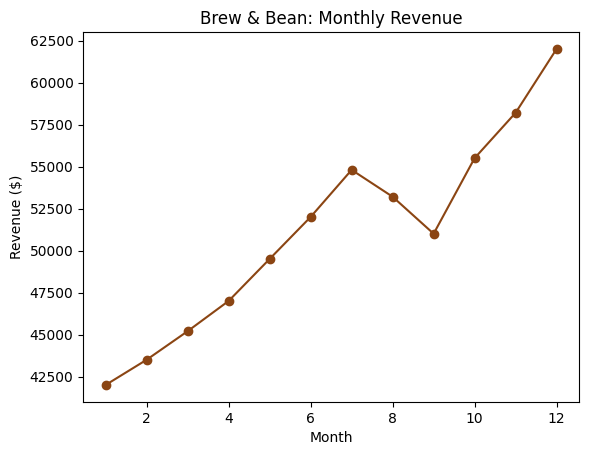

In [ ]:
# YOUR CODE HERE
# Hint: plt.plot(x, y), then plt.title(), plt.xlabel(), plt.ylabel(), plt.show()

plt.plot(monthly_sales_df["month"], monthly_sales_df["revenue"], marker='o', color='saddlebrown')
plt.title("Brew & Bean: Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()

**Question 2: Bar Chart**
Using `regional_df`, plot total revenue by region using `plt.bar()`. Add a title and axis labels.

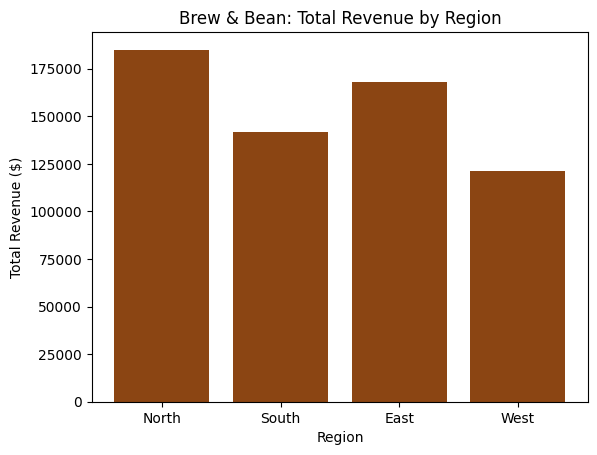

In [ ]:
# YOUR CODE HERE
# Hint: plt.bar(x, height)

plt.bar(regional_df["region"], regional_df["total_revenue"], color='saddlebrown')
plt.title("Brew & Bean: Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")
plt.show()

**Question 3: Histogram**
Using `transactions_df`, plot the distribution of `transaction_amount` using `plt.hist()`, with 15 bins.

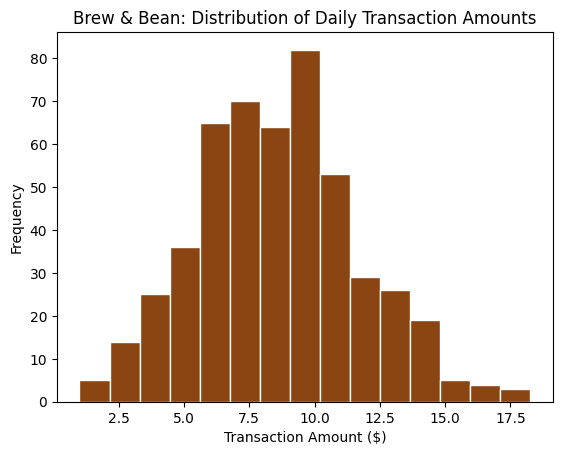

In [ ]:
# YOUR CODE HERE
# Hint: plt.hist(data, bins=...)

plt.hist(transactions_df["transaction_amount"], bins=15, color='saddlebrown', edgecolor='white')
plt.title("Brew & Bean: Distribution of Daily Transaction Amounts")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")
plt.show()

**Question 4: Boxplot**
Using `category_df`, plot a boxplot comparing `revenue` across all four categories using `plt.boxplot()`. You'll need to build the list of arrays first, the same way we did earlier.

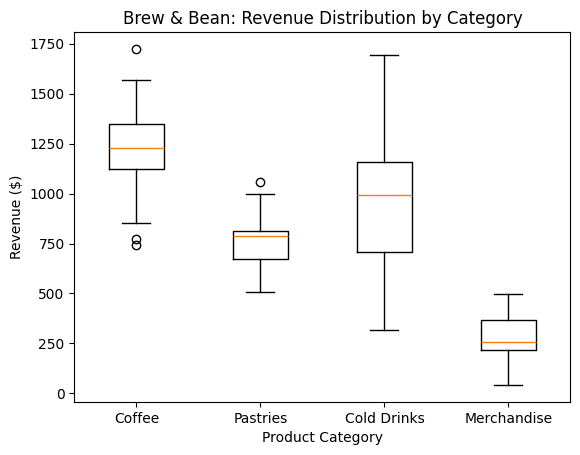

In [ ]:
# YOUR CODE HERE
# Hint: build "data" as a list of Series (one per category), then plt.boxplot(data, tick_labels=categories)

data = [category_df[category_df["category"] == cat]["revenue"] for cat in categories]
plt.boxplot(data, tick_labels=categories)
plt.title("Brew & Bean: Revenue Distribution by Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.show()

**Question 5: Subplots**
Recreate the revenue trend + regional revenue side-by-side Figure from earlier, but this time using the **implicit interface** with `plt.subplot(nrows, ncols, index)` instead of `ax1`/`ax2`.

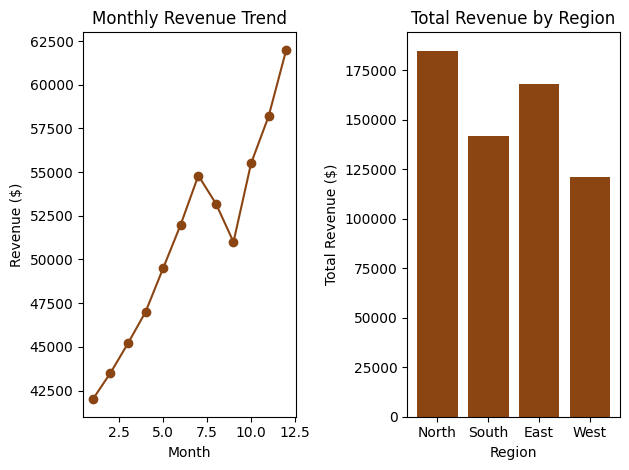

In [ ]:
# YOUR CODE HERE
# Hint: plt.subplot(1, 2, 1) -> plot the line chart -> plt.subplot(1, 2, 2) -> plot the bar chart -> plt.show()

plt.subplot(1, 2, 1)
plt.plot(monthly_sales_df["month"], monthly_sales_df["revenue"], marker='o', color='saddlebrown')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.subplot(1, 2, 2)
plt.bar(regional_df["region"], regional_df["total_revenue"], color='saddlebrown')
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()

### Classwork

**Question 1: Handling Missing Values**

Check `penguins` for missing values. Decide how you want to handle them (leave as is, drop rows, or fill them), and briefly justify your choice in a markdown cell.

In [ ]:
# YOUR CODE HERE
# Hint: penguins.isnull().sum() to check, then .dropna() or .fillna() if you choose to handle them

In [ ]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [ ]:
penguins_clean = penguins.dropna()
penguins_clean.shape

(333, 7)

_Justification: dropped rows with missing values rather than filling them, since only 11 out of 344 rows are affected (~3%) — small enough that dropping won't meaningfully bias the analysis, and filling categorical (`sex`) or measurement columns with guessed values could distort species-level comparisons._

_Your justification here._

**Question 2: Scatterplot**

Using Seaborn, create a scatterplot of `bill_length_mm` vs `bill_depth_mm`, colored by `species`. What pattern do you notice between the three species?

In [ ]:
# YOUR CODE HERE
# Hint: sns.scatterplot(data=..., x=..., y=..., hue=...)

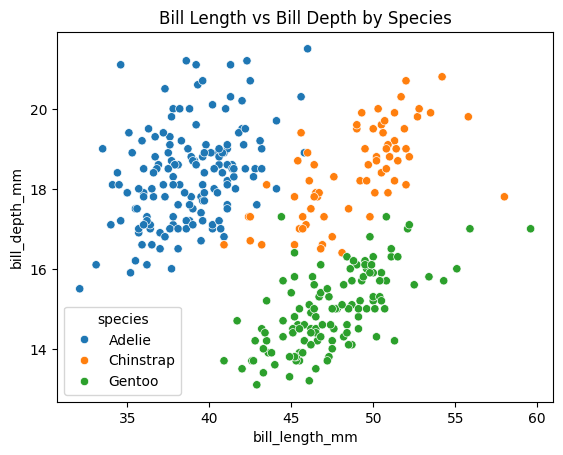

In [ ]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Bill Length vs Bill Depth by Species")
plt.show()

_Your observation here._

**Question 3: Boxplot or Violin Plot**

Using Seaborn, compare `body_mass_g` across the three `species`, using either a boxplot or a violin plot (your choice). Which species tends to be heaviest? Are there any outliers?

In [ ]:
# YOUR CODE HERE
# Hint: sns.boxplot(data=..., x='species', y='body_mass_g') or sns.violinplot(...)

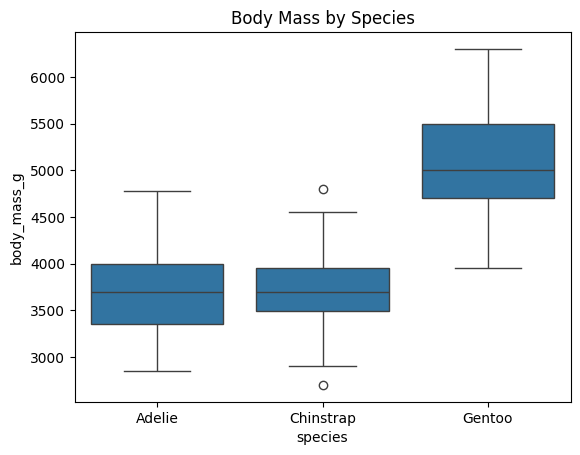

In [ ]:
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Body Mass by Species")
plt.show()

_Your observation here._

**Question 4: Bar Chart**

Using Seaborn's `countplot`, show how many penguins were observed on each `island`. Which island has the most observations?

In [ ]:
# YOUR CODE HERE
# Hint: sns.countplot(data=..., x='island')

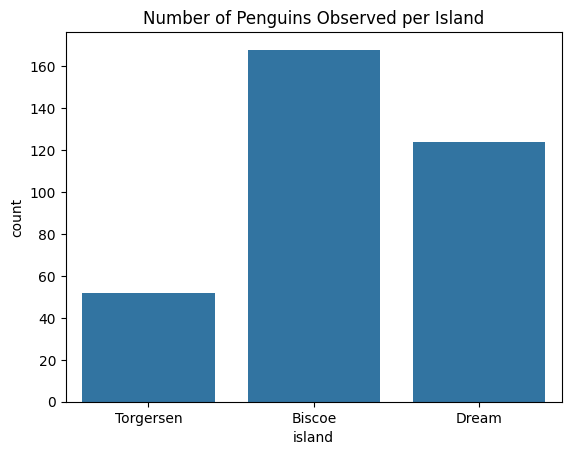

In [ ]:
sns.countplot(data=penguins, x="island")
plt.title("Number of Penguins Observed per Island")
plt.show()

_Your observation here._

**Question 5: Heatmap**

Compute the correlation matrix for the numeric columns in `penguins`, then visualize it as a heatmap. Which two measurements are most strongly correlated?

In [ ]:
# YOUR CODE HERE
# Hint: penguins.corr(numeric_only=True), then sns.heatmap(corr, annot=True)

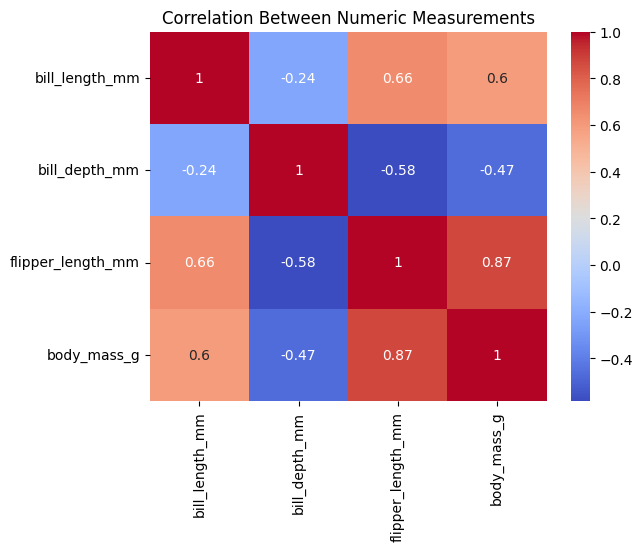

In [ ]:
corr = penguins.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Measurements")
plt.show()

_Your observation here._

**Question 6: Subplots**

Create a Figure with **2 subplots side by side**: on the left, a scatterplot of `bill_length_mm` vs `bill_depth_mm` colored by `species`; on the right, a boxplot of `body_mass_g` by `species`. Use the explicit interface (`fig, (ax1, ax2) = plt.subplots(1, 2, ...)`), and remember Seaborn functions accept an `ax=` argument to tell them which subplot to draw on.

In [ ]:
# YOUR CODE HERE
# Hint: fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# sns.scatterplot(..., ax=ax1)
# sns.boxplot(..., ax=ax2)

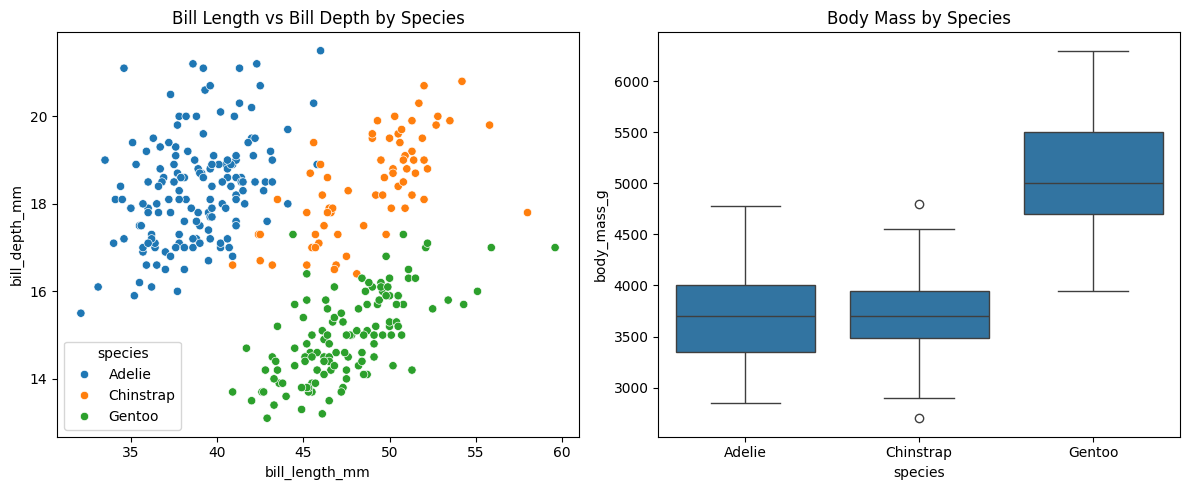

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=ax1)
ax1.set_title("Bill Length vs Bill Depth by Species")

sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax2)
ax2.set_title("Body Mass by Species")

plt.tight_layout()
plt.show()

_Your observation here._

**Question 7: Male vs. Female Body Mass**

Is there a meaningful difference in `body_mass_g` between male and female penguins? Choose whatever chart type you think best answers this (from anything we've covered, Matplotlib, Seaborn, or Plotly), and justify why you picked it.

In [ ]:
# YOUR CODE HERE

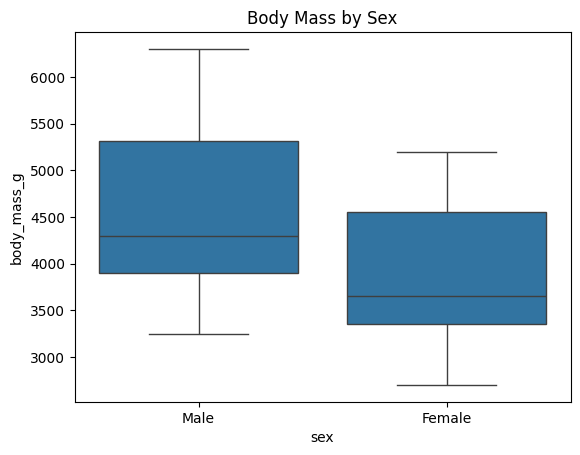

In [ ]:
sns.boxplot(data=penguins, x="sex", y="body_mass_g")
plt.title("Body Mass by Sex")
plt.show()

_Your chart choice and justification here._

**Question 8: Species Distribution Across Islands**

Do certain penguin species tend to live on certain islands, or are all three species spread evenly across all islands? Choose a chart type that best reveals this relationship, and justify your choice.

In [ ]:
# YOUR CODE HERE

In [ ]:
pd.crosstab(penguins["species"], penguins["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


_Your chart choice and justification here._

**Question 9: Interactive Plotly Chart**

Using Plotly, create an interactive scatter plot of `flipper_length_mm` vs `body_mass_g`, colored by `species`, with `hover_name` showing the `island`. Hover over a few points, do you see anything interesting about how flipper length and body mass relate within each species?

In [ ]:
# YOUR CODE HERE
# Hint: px.scatter(df, x=..., y=..., color='species', hover_name='island')

In [ ]:
fig = px.scatter(penguins, x="flipper_length_mm", y="body_mass_g", color="species", hover_name="island")
fig.show()

_Your observation here._